/Users/jonathanperez/cse-144/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu
Full training size: 1079
First 10 classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm

Epoch 1/20 | lr: 0.001000 | train_loss: 4.6359 | train_acc: 0.0482


Epoch 2/20 | lr: 0.001000 | train_loss: 3.6641 | train_acc: 0.1724


Epoch 3/20 | lr: 0.001000 | train_loss: 3.1619 | train_acc: 0.2771


...

Epoch 16/20 | lr: 0.000075 | train_loss: 0.9433 | train_acc: 0.9972


Epoch 17/20 | lr: 0.000075 | train_loss: 0.9381 | train_acc: 0.9963


Epoch 18/20 | lr: 0.000075 | train_loss: 0.9323 | train_acc: 0.9981


Epoch 19/20 | lr: 0.000075 | train_loss: 0.9192 | train_acc: 1.0000


Epoch 20/20 | lr: 0.000037 | train_loss: 0.9249 | train_acc: 0.9972
Saved final model to /Users/jonathanperez/cse-144/project/cse144-final/final_single_model_seed999.pt


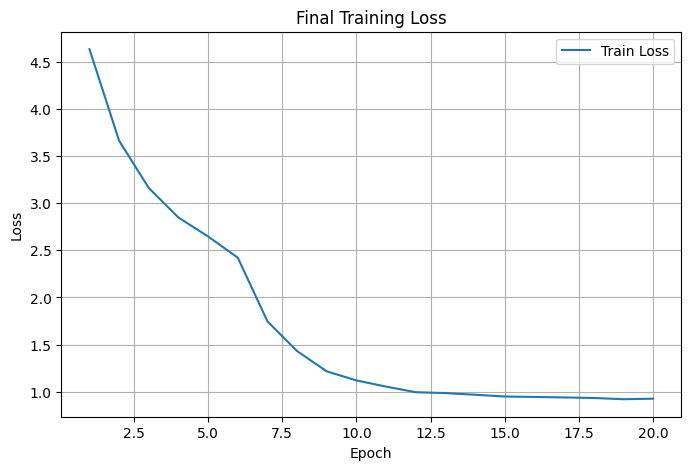

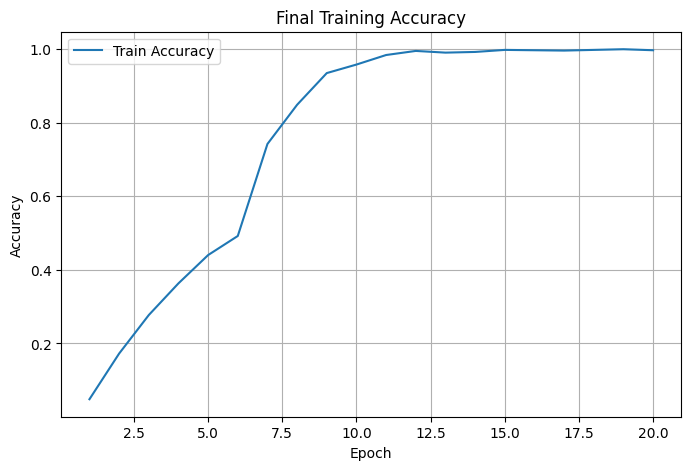

100%|██████████| 33/33 [00:38<00:00,  1.16s/it]

Saved submission to /Users/jonathanperez/cse-144/project/cse144-final/submission_final_single_model.csv
Submission file: /Users/jonathanperez/cse-144/project/cse144-final/submission_final_single_model.csv


In [1]:
# CSE 144 Final Project
# Transfer Learning Challenge

import os
import csv
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms, datasets
from tqdm.auto import tqdm


# =========================================================
# 0. Reproducibility
# =========================================================
SEED = 999

def set_seed(seed: int = 999):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning:", e)

set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


# =========================================================
# 1. Paths / constants
# =========================================================
DATA_DIR = os.path.join(os.getcwd(), "ucsc-cse-144-winter-2026-final-project")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

NUM_CLASSES = 100
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 if device == "cuda" else 0

# Final full-data training length:
# use the best recipe you found during validation experiments
NUM_EPOCHS = 20
FREEZE_EPOCHS = 5

FINAL_MODEL_PATH = os.path.join(os.getcwd(), "final_single_model_seed999.pt")


# =========================================================
# 2. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 3. Custom ImageFolder with fixed numeric class mapping
# =========================================================
class NumericImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes = [d.name for d in os.scandir(directory) if d.is_dir()]
        classes = sorted(classes, key=lambda x: int(x))
        class_to_idx = {cls_name: int(cls_name) for cls_name in classes}
        return classes, class_to_idx


# =========================================================
# 4. Load full labeled training dataset
# =========================================================
full_train_dataset = NumericImageFolder(TRAIN_DIR, transform=train_transform)

for i in range(NUM_CLASSES):
    assert full_train_dataset.class_to_idx[str(i)] == i, f"Class mapping broken for class {i}"

print("Full training size:", len(full_train_dataset))
print("First 10 classes:", full_train_dataset.classes[:10])


# =========================================================
# 5. DataLoader
# =========================================================
train_loader = DataLoader(
    full_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda")
)


# =========================================================
# 6. Model: ResNet18
# =========================================================
def get_model(num_classes=NUM_CLASSES, freeze_backbone=True):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )

    for param in model.fc.parameters():
        param.requires_grad = True

    return model


def unfreeze_last_block(model):
    for param in model.layer4.parameters():
        param.requires_grad = True


model = get_model().to(device)
print(model)


# =========================================================
# 7. Loss / optimizer / scheduler
# =========================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)


# =========================================================
# 8. Training function
# =========================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


# =========================================================
# 9. Final training loop on all labeled data
# =========================================================
history = {"train_loss": [], "train_acc": []}

for epoch in range(NUM_EPOCHS):
    if epoch == FREEZE_EPOCHS:
        print("\nUnfreezing ResNet layer4...\n")
        unfreeze_last_block(model)

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=3e-4,
            weight_decay=2e-4
        )

        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=5,
            gamma=0.5
        )

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"lr: {current_lr:.6f} | "
        f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}"
    )

torch.save({
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "class_to_idx": full_train_dataset.class_to_idx
}, FINAL_MODEL_PATH)

print(f"Saved final model to {FINAL_MODEL_PATH}")


# =========================================================
# 10. Plot training curves
# =========================================================
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 11. Kaggle test dataset
# =========================================================
class TestImageDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_files = sorted(
            [f for f in os.listdir(test_dir) if f.endswith(".jpg")],
            key=lambda x: int(os.path.splitext(x)[0])
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        path = os.path.join(self.test_dir, fname)
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, fname


test_dataset = TestImageDataset(TEST_DIR, transform=test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda")
)


# =========================================================
# 12. Prediction with single-model TTA
# =========================================================
@torch.no_grad()
def predict_test(model_path, device="cpu"):
    model = get_model(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)

    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    predictions = []

    for images, fnames in tqdm(test_loader):
        images = images.to(device)
        flipped_images = torch.flip(images, dims=[3])

        outputs_1 = model(images)
        outputs_2 = model(flipped_images)
        outputs = (outputs_1 + outputs_2) / 2.0

        preds = outputs.argmax(dim=1).cpu().tolist()

        for fname, pred in zip(fnames, preds):
            predictions.append((fname, pred))

    out_path = os.path.join(os.getcwd(), "submission_final_single_model.csv")
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Label"])
        writer.writerows(predictions)

    print(f"Saved submission to {out_path}")
    return out_path


submission_path = predict_test(FINAL_MODEL_PATH, device=device)
print("Submission file:", submission_path)

In [ ]:
import os
import csv
import torch
from tqdm import tqdm

MODEL_PATHS = [
    os.path.join(os.getcwd(), "best_model_seed42.pt"),
    # os.path.join(os.getcwd(), "best_model_seed123.pt"),
    os.path.join(os.getcwd(), "best_model_seed999.pt"),
]

@torch.no_grad()
def predict_test_ensemble(model_paths, device="cpu"):
    ensemble_models = []

    for model_path in model_paths:
        model = get_model(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        ensemble_models.append(model)

    predictions = []

    for images, fnames in tqdm(test_loader):
        images = images.to(device)
        flipped_images = torch.flip(images, dims=[3])  # horizontal flip TTA

        avg_logits = None

        for model in ensemble_models:
            logits_original = model(images)
            logits_flipped = model(flipped_images)
            logits = (logits_original + logits_flipped) / 2.0

            if avg_logits is None:
                avg_logits = logits
            else:
                avg_logits += logits

        avg_logits = avg_logits / len(ensemble_models)
        preds = avg_logits.argmax(dim=1).cpu().tolist()

        for fname, pred in zip(fnames, preds):
            predictions.append((fname, pred))

    out_path = os.path.join(os.getcwd(), "submission_ensemble.csv")
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Label"])
        writer.writerows(predictions)

    print(f"Saved ensemble submission to {out_path}")
    return out_path

submission_path = predict_test_ensemble(MODEL_PATHS, device=device)
print("Submission file:", submission_path)